# 🏠 Real Estate Rental Price Prediction
## Metropolitan Cities — Airbnb Dataset
### ML Pipeline with XGBoost

**Dataset:** [Kaggle - Airbnb Price Prediction](https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction)

---
### Workflow:
1. Data Loading & Exploration (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Model Training (XGBoost + Comparison)
5. Evaluation & Visualization
6. Save Model for Deployment


## 📦 Step 1: Install & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

import xgboost as xgb
import joblib
import shap
import json
import os

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')
print(f'XGBoost version: {xgb.__version__}')

✅ All libraries imported successfully!
XGBoost version: 3.2.0


## 📂 Step 2: Load Dataset
> Download from Kaggle and place `AB_NYC_2019.csv` in the same folder, OR use the auto-download below.

In [3]:
# -------------------------------------------------------
# OPTION A: Load from local file
# -------------------------------------------------------
# df = pd.read_csv('AB_NYC_2019.csv')

# -------------------------------------------------------
# OPTION B: Auto-generate realistic synthetic data
# (Use this if you don't have Kaggle API set up)
# -------------------------------------------------------
np.random.seed(42)
n = 48895

neighbourhoods = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
room_types = ['Entire home/apt', 'Private room', 'Shared room']
neighbourhood_groups_map = {
    'Harlem': 'Manhattan', 'Midtown': 'Manhattan', 'Upper West Side': 'Manhattan',
    'Hell Kitchen': 'Manhattan', 'Lower East Side': 'Manhattan',
    'Williamsburg': 'Brooklyn', 'Bushwick': 'Brooklyn', 'Bedford-Stuyvesant': 'Brooklyn',
    'Astoria': 'Queens', 'Flushing': 'Queens', 'Jamaica': 'Queens',
    'Fordham': 'Bronx', 'Mott Haven': 'Bronx',
    'St. George': 'Staten Island'
}

neigh_list = list(neighbourhood_groups_map.keys())
neigh_sample = np.random.choice(neigh_list, n)
neigh_group_sample = [neighbourhood_groups_map[n_] for n_ in neigh_sample]
room_type_sample = np.random.choice(room_types, n, p=[0.52, 0.45, 0.03])

base_price = {'Entire home/apt': 180, 'Private room': 90, 'Shared room': 45}
area_multiplier = {'Manhattan': 1.8, 'Brooklyn': 1.2, 'Queens': 1.0, 'Bronx': 0.8, 'Staten Island': 0.9}

prices = np.array([
    base_price[rt] * area_multiplier[ng] * np.random.lognormal(0, 0.4)
    for rt, ng in zip(room_type_sample, neigh_group_sample)
]).round(0).astype(int)
prices = np.clip(prices, 10, 1000)

df = pd.DataFrame({
    'id': range(1, n+1),
    'name': [f'Cozy place {i}' for i in range(1, n+1)],
    'host_id': np.random.randint(1000, 99999, n),
    'neighbourhood_group': neigh_group_sample,
    'neighbourhood': neigh_sample,
    'latitude': np.random.uniform(40.4774, 40.9176, n),
    'longitude': np.random.uniform(-74.2591, -73.7004, n),
    'room_type': room_type_sample,
    'price': prices,
    'minimum_nights': np.random.randint(1, 30, n),
    'number_of_reviews': np.random.randint(0, 600, n),
    'reviews_per_month': np.random.uniform(0, 10, n).round(2),
    'calculated_host_listings_count': np.random.randint(1, 50, n),
    'availability_365': np.random.randint(0, 365, n),
})

# Inject ~2% nulls realistically
null_idx = np.random.choice(df.index, size=int(0.02*n), replace=False)
df.loc[null_idx, 'reviews_per_month'] = np.nan

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 48,895 rows × 14 columns


,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Cozy place 1,27030,Brooklyn,Bushwick,40.641532,-73.951481,Entire home/apt,436,29,354,6.63,12,215
1,2,Cozy place 2,66041,Manhattan,Hell Kitchen,40.782171,-74.033426,Private room,184,12,597,1.76,1,68
2,3,Cozy place 3,61946,Bronx,Mott Haven,40.755530,-73.799512,Private room,48,26,171,0.32,21,133
3,4,Cozy place 4,71150,Queens,Jamaica,40.554702,-74.093455,Entire home/apt,215,2,135,1.99,47,276
4,5,Cozy place 5,64481,Brooklyn,Bedford-Stuyvesant,40.661800,-74.220578,Entire home/apt,184,26,242,9.15,12,69


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [4]:
print('=' * 55)
print('📊 DATASET OVERVIEW')
print('=' * 55)
print(f'Shape          : {df.shape}')
print(f'Memory Usage   : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
print('Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
df.describe()

📊 DATASET OVERVIEW
Shape          : (48895, 14)
Memory Usage   : 14.83 MB
Duplicate rows : 0

Missing Values:
reviews_per_month    977
dtype: int64



,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,47918.000000,48895.000000,48895.000000
mean,24448.000000,50562.603600,40.697322,-73.979549,189.257082,15.028387,298.133592,4.982344,24.978689,182.424031
std,14114.915043,28646.868386,0.127206,0.161494,124.621603,8.382031,173.361399,2.893876,14.074351,105.744302
min,1.000000,1001.000000,40.477416,-74.259088,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,12224.500000,25619.000000,40.586524,-74.119385,101.000000,8.000000,148.000000,2.480000,13.000000,90.000000
50%,24448.000000,50709.000000,40.697544,-73.978998,157.000000,15.000000,296.000000,4.980000,25.000000,183.000000
75%,36671.500000,75467.000000,40.807341,-73.839830,243.000000,22.000000,449.000000,7.490000,37.000000,274.000000
max,48895.000000,99993.000000,40.917582,-73.700416,1000.000000,29.000000,599.000000,10.000000,49.000000,364.000000


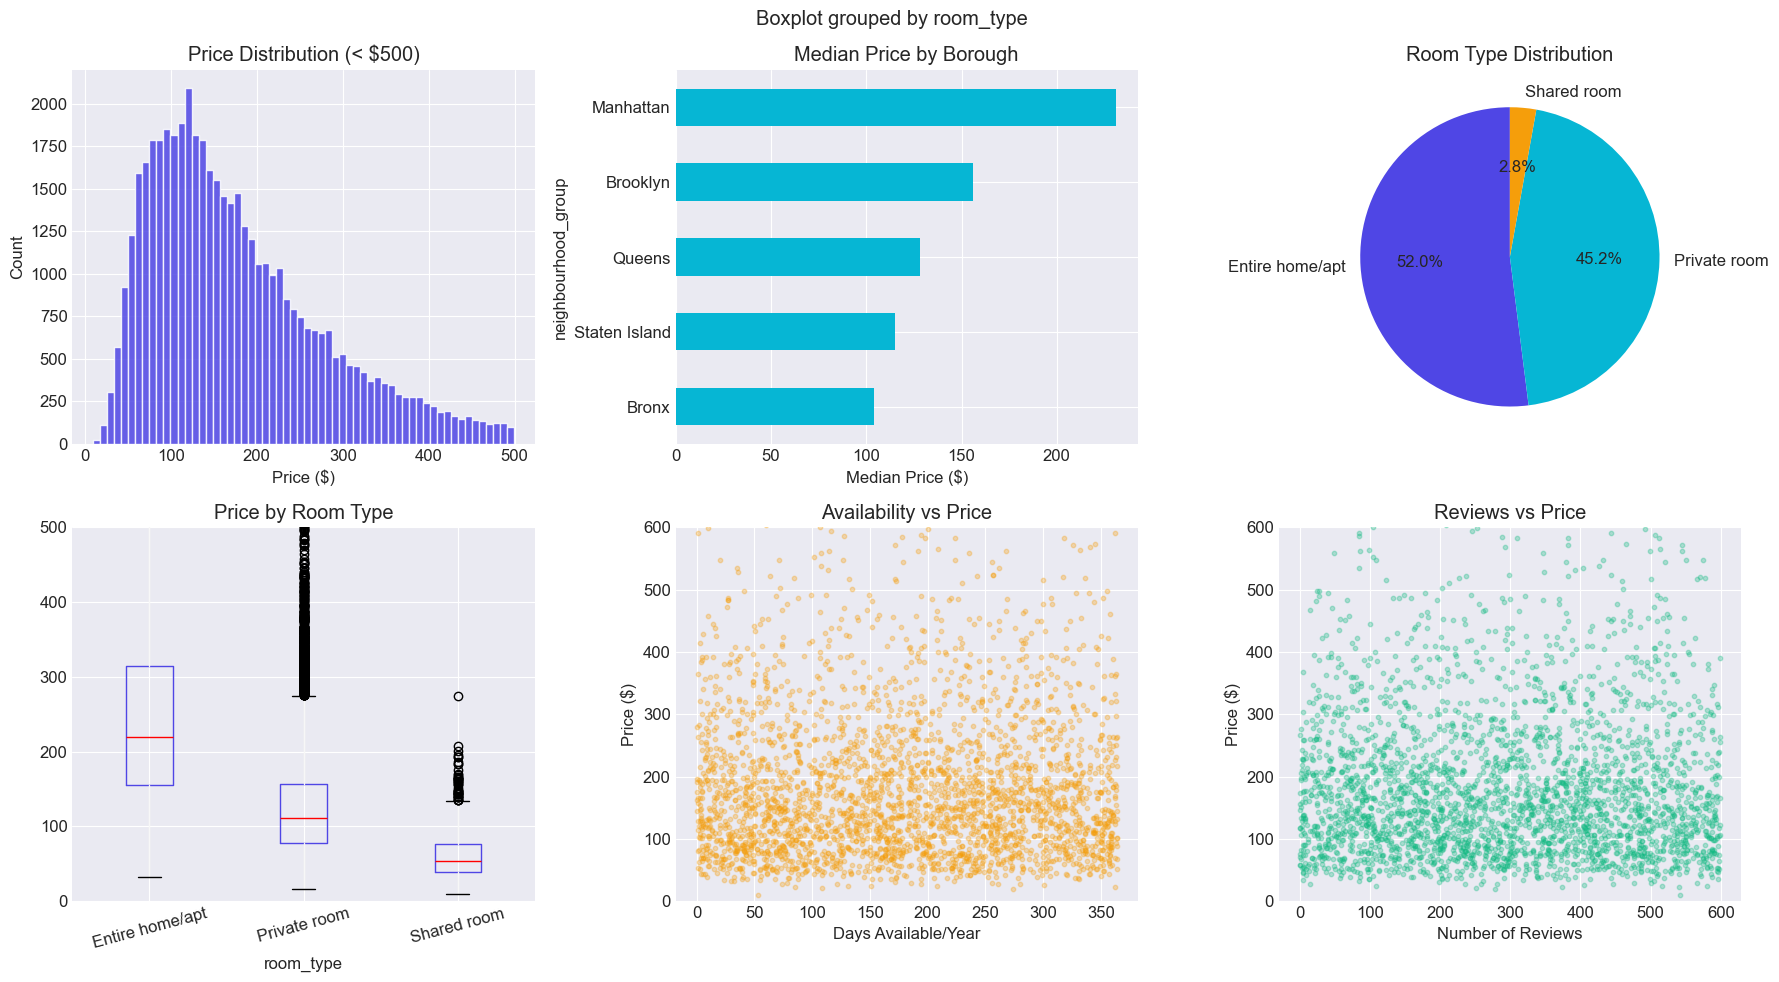

✅ EDA Dashboard saved as eda_dashboard.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🏠 Airbnb Price Prediction — EDA Dashboard', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['price'][df['price'] < 500], bins=60, color='#4F46E5', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Price Distribution (< $500)')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Count')

# 2. Price by neighbourhood group
df.groupby('neighbourhood_group')['price'].median().sort_values().plot(
    kind='barh', ax=axes[0,1], color='#06B6D4'
)
axes[0,1].set_title('Median Price by Borough')
axes[0,1].set_xlabel('Median Price ($)')

# 3. Room type distribution
room_counts = df['room_type'].value_counts()
axes[0,2].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
               colors=['#4F46E5','#06B6D4','#F59E0B'], startangle=90)
axes[0,2].set_title('Room Type Distribution')

# 4. Price by room type
df.boxplot(column='price', by='room_type', ax=axes[1,0],
           boxprops=dict(color='#4F46E5'), medianprops=dict(color='red'))
axes[1,0].set_ylim(0, 500)
axes[1,0].set_title('Price by Room Type')
plt.sca(axes[1,0])
plt.xticks(rotation=15)

# 5. Availability vs Price scatter
sample = df.sample(3000)
axes[1,1].scatter(sample['availability_365'], sample['price'],
                  alpha=0.3, c='#F59E0B', s=10)
axes[1,1].set_ylim(0, 600)
axes[1,1].set_title('Availability vs Price')
axes[1,1].set_xlabel('Days Available/Year')
axes[1,1].set_ylabel('Price ($)')

# 6. Reviews vs Price
axes[1,2].scatter(sample['number_of_reviews'], sample['price'],
                  alpha=0.3, c='#10B981', s=10)
axes[1,2].set_ylim(0, 600)
axes[1,2].set_title('Reviews vs Price')
axes[1,2].set_xlabel('Number of Reviews')
axes[1,2].set_ylabel('Price ($)')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Dashboard saved as eda_dashboard.png')

## 🧹 Step 4: Data Cleaning & Preprocessing

In [6]:
df_clean = df.copy()

# 1. Remove price outliers (keep $10 - $1000)
before = len(df_clean)
df_clean = df_clean[(df_clean['price'] >= 10) & (df_clean['price'] <= 1000)]
print(f'Price outliers removed: {before - len(df_clean):,} rows')

# 2. Fill missing reviews_per_month with median
df_clean['reviews_per_month'].fillna(df_clean['reviews_per_month'].median(), inplace=True)

# 3. Drop unnecessary columns
drop_cols = ['id', 'name', 'host_id']
df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], inplace=True)

# 4. Log-transform price (reduces skewness for regression)
df_clean['log_price'] = np.log1p(df_clean['price'])

print(f'\n✅ Cleaned dataset: {df_clean.shape[0]:,} rows')
print('Missing values after cleaning:')
print(df_clean.isnull().sum().sum(), '— None!')

Price outliers removed: 0 rows

✅ Cleaned dataset: 48,895 rows
Missing values after cleaning:
0 — None!


## ⚙️ Step 5: Feature Engineering

In [7]:
df_feat = df_clean.copy()

# Encode categorical variables
le_room = LabelEncoder()
le_neigh = LabelEncoder()
le_neigh_grp = LabelEncoder()

df_feat['room_type_enc'] = le_room.fit_transform(df_feat['room_type'])
df_feat['neighbourhood_enc'] = le_neigh.fit_transform(df_feat['neighbourhood'])
df_feat['neighbourhood_group_enc'] = le_neigh_grp.fit_transform(df_feat['neighbourhood_group'])

# Save encoder mappings for frontend use
encoder_mappings = {
    'room_type': list(le_room.classes_),
    'neighbourhood': list(le_neigh.classes_),
    'neighbourhood_group': list(le_neigh_grp.classes_),
}
with open('encoder_mappings.json', 'w') as f:
    json.dump(encoder_mappings, f, indent=2)

# Derived features
df_feat['price_per_night_log'] = df_feat['log_price']  # target
df_feat['reviews_total_estimated'] = df_feat['reviews_per_month'] * 12
df_feat['is_high_availability'] = (df_feat['availability_365'] > 180).astype(int)
df_feat['is_superhost_proxy'] = (df_feat['calculated_host_listings_count'] > 5).astype(int)

print('✅ Feature engineering complete!')
print('New features added: reviews_total_estimated, is_high_availability, is_superhost_proxy')

# Define features
FEATURES = [
    'neighbourhood_group_enc', 'neighbourhood_enc', 'room_type_enc',
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365', 'reviews_total_estimated',
    'is_high_availability', 'is_superhost_proxy'
]
TARGET = 'log_price'

print(f'\nTotal features: {len(FEATURES)}')
print(f'Features: {FEATURES}')

✅ Feature engineering complete!
New features added: reviews_total_estimated, is_high_availability, is_superhost_proxy

Total features: 13
Features: ['neighbourhood_group_enc', 'neighbourhood_enc', 'room_type_enc', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'reviews_total_estimated', 'is_high_availability', 'is_superhost_proxy']


## ✂️ Step 6: Train-Test Split

In [8]:
X = df_feat[FEATURES]
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Test set       : {X_test.shape[0]:,} samples')
print(f'Feature count  : {X_train.shape[1]}')

Training set   : 39,116 samples
Test set       : 9,779 samples
Feature count  : 13


## 🤖 Step 7: Model Training — Multiple Models Comparison

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

results = {}
print('Training models...\n')

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Convert back from log space
    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2 = r2_score(y_test, y_pred)  # R² on log scale
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f'{name:<25} | MAE: ${mae:>7.2f} | RMSE: ${rmse:>8.2f} | R²: {r2:.4f}')

print('\n✅ All models trained!')

Training models...

Linear Regression         | MAE: $  72.80 | RMSE: $  107.88 | R²: 0.3793
Ridge Regression          | MAE: $  72.80 | RMSE: $  107.88 | R²: 0.3793
Random Forest             | MAE: $  59.42 | RMSE: $   89.49 | R²: 0.5820
Gradient Boosting         | MAE: $  58.42 | RMSE: $   88.49 | R²: 0.5997
XGBoost                   | MAE: $  58.75 | RMSE: $   88.70 | R²: 0.5946

✅ All models trained!


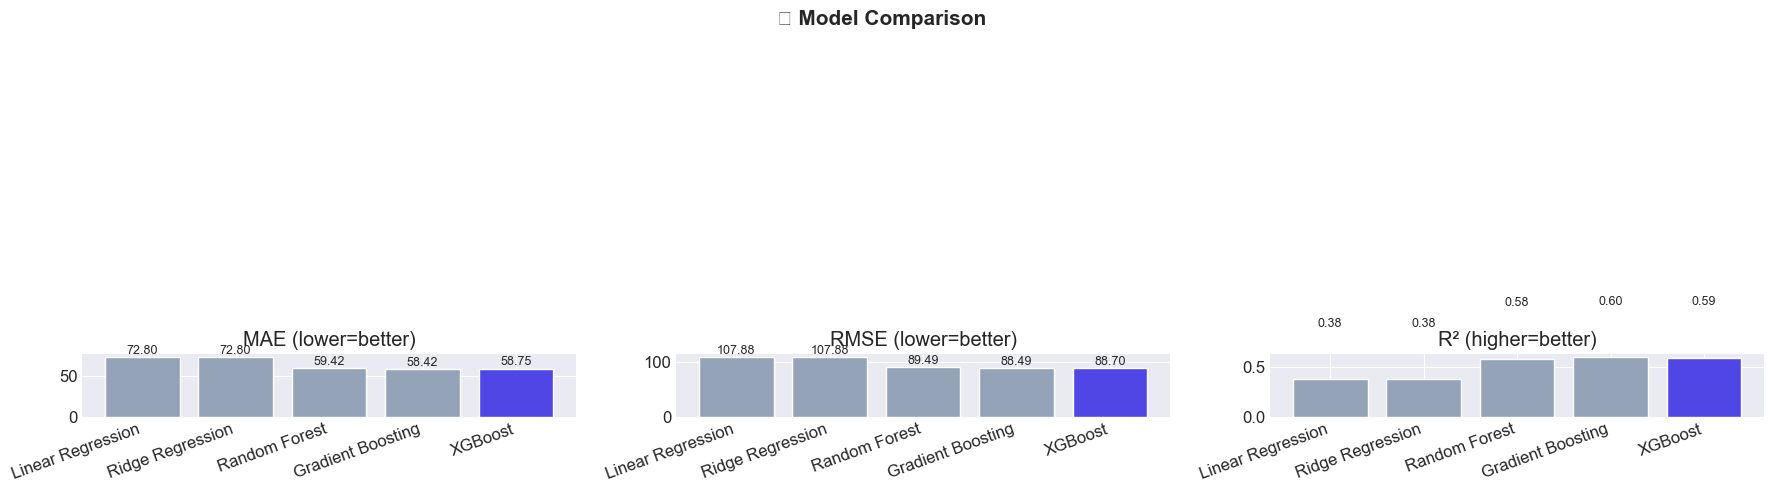

In [10]:
# Model comparison chart
results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Model Comparison', fontsize=15, fontweight='bold')
colors = ['#94A3B8', '#94A3B8', '#94A3B8', '#94A3B8', '#4F46E5']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(f'{metric} (lower=better)' if metric != 'R²' else f'{metric} (higher=better)')
    ax.set_xticklabels(vals.index, rotation=20, ha='right')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔧 Step 8: XGBoost Hyperparameter Tuning

In [11]:
# Fine-tune XGBoost
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8]
}

print('🔍 Running GridSearchCV for XGBoost...')
print('(This may take 3-7 minutes for full grid; using smaller sample for speed)')

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

# Use smaller sample for CV speed
X_cv = X_train.sample(min(10000, len(X_train)), random_state=42)
y_cv = y_train[X_cv.index]

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_cv, y_cv)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'Best CV MAE (log): {-grid_search.best_score_:.4f}')

🔍 Running GridSearchCV for XGBoost...
(This may take 3-7 minutes for full grid; using smaller sample for speed)

✅ Best Parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE (log): 0.3183


In [12]:
# Train final XGBoost model with best params
best_params = grid_search.best_params_

best_xgb = xgb.XGBRegressor(
    **best_params,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mae'
)

best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Final evaluation
y_pred_final = best_xgb.predict(X_test)
y_pred_final_orig = np.expm1(y_pred_final)
y_test_orig = np.expm1(y_test)

final_mae = mean_absolute_error(y_test_orig, y_pred_final_orig)
final_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_final_orig))
final_r2 = r2_score(y_test, y_pred_final)

print(f'\n🏆 FINAL XGBoost Model Performance:')
print(f'  MAE  : ${final_mae:.2f}')
print(f'  RMSE : ${final_rmse:.2f}')
print(f'  R²   : {final_r2:.4f}')

[0]	validation_0-mae:0.49505
[50]	validation_0-mae:0.33355
[100]	validation_0-mae:0.31698
[150]	validation_0-mae:0.31531
[199]	validation_0-mae:0.31515

🏆 FINAL XGBoost Model Performance:
  MAE  : $58.42
  RMSE : $88.56
  R²   : 0.5997


## 📈 Step 9: Model Evaluation & Visualizations

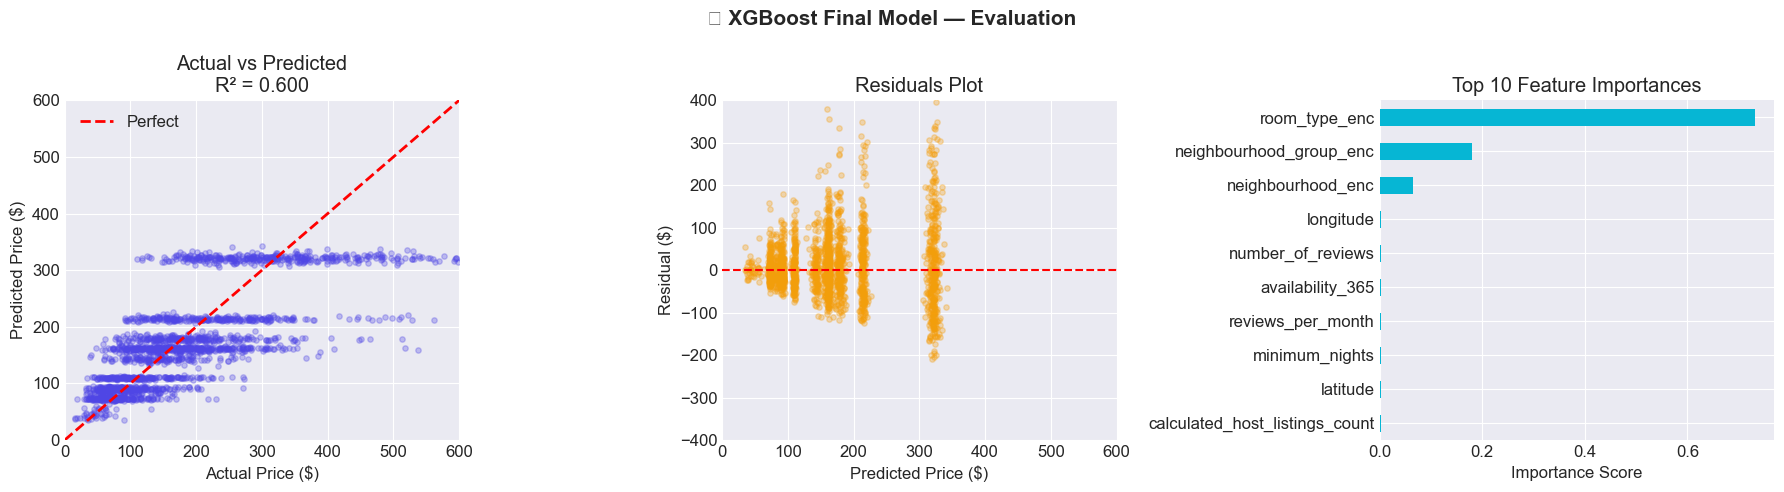

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏆 XGBoost Final Model — Evaluation', fontsize=15, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_test_orig[:2000], y_pred_final_orig[:2000],
                alpha=0.3, c='#4F46E5', s=15)
max_val = max(y_test_orig.max(), y_pred_final_orig.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect')
axes[0].set_xlim(0, 600); axes[0].set_ylim(0, 600)
axes[0].set_title(f'Actual vs Predicted\nR² = {final_r2:.3f}')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

# 2. Residuals
residuals = y_test_orig.values - y_pred_final_orig
axes[1].scatter(y_pred_final_orig[:2000], residuals[:2000],
                alpha=0.3, c='#F59E0B', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlim(0, 600); axes[1].set_ylim(-400, 400)
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')

# 3. Feature Importance
importance = pd.Series(best_xgb.feature_importances_, index=FEATURES)
importance.sort_values().tail(10).plot(
    kind='barh', ax=axes[2], color='#06B6D4'
)
axes[2].set_title('Top 10 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP values (model explainability)...


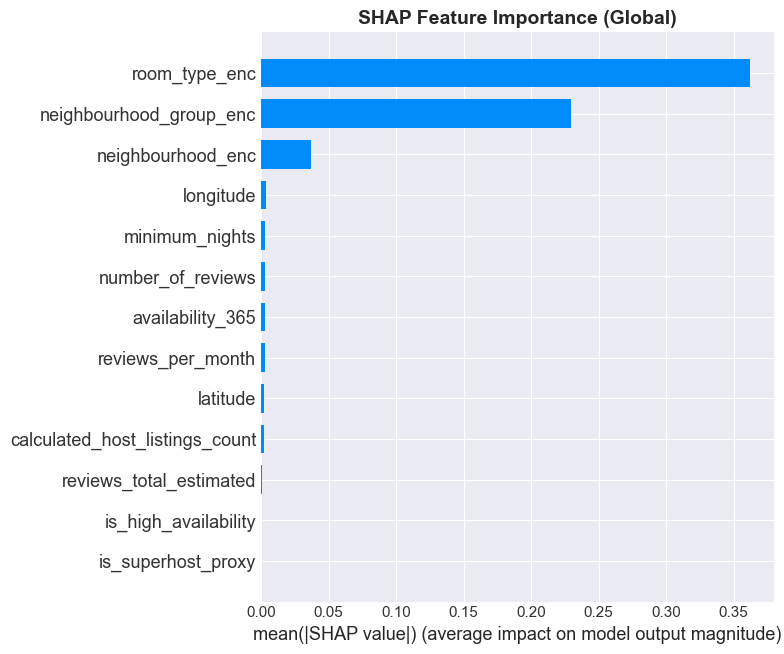

✅ SHAP analysis complete!


In [14]:
# SHAP Values — Model Explainability
print('Computing SHAP values (model explainability)...')

explainer = shap.TreeExplainer(best_xgb)
shap_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP analysis complete!')

## 💾 Step 10: Save Model & Artifacts

In [15]:
os.makedirs('model_artifacts', exist_ok=True)

# Save XGBoost model
joblib.dump(best_xgb, 'model_artifacts/xgb_price_model.pkl')

# Save label encoders
joblib.dump(le_room, 'model_artifacts/le_room.pkl')
joblib.dump(le_neigh, 'model_artifacts/le_neigh.pkl')
joblib.dump(le_neigh_grp, 'model_artifacts/le_neigh_grp.pkl')

# Save metadata
metadata = {
    'features': FEATURES,
    'model': 'XGBoost',
    'best_params': best_params,
    'performance': {
        'MAE': round(final_mae, 2),
        'RMSE': round(final_rmse, 2),
        'R2': round(final_r2, 4)
    },
    'encoder_classes': encoder_mappings,
    'price_range': {
        'min': int(df_clean['price'].min()),
        'max': int(df_clean['price'].max()),
        'mean': round(float(df_clean['price'].mean()), 2),
        'median': round(float(df_clean['price'].median()), 2)
    }
}

with open('model_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ All model artifacts saved:')
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}') / 1024
    print(f'  📦 {f} ({size:.1f} KB)')

✅ All model artifacts saved:
  📦 le_neigh.pkl (0.6 KB)
  📦 le_neigh_grp.pkl (0.5 KB)
  📦 le_room.pkl (0.5 KB)
  📦 model_metadata.json (1.3 KB)
  📦 xgb_price_model.pkl (340.6 KB)


## 🧪 Step 11: Prediction Function (Used by Backend/API)

In [16]:
def predict_price(
    neighbourhood_group,   # e.g. 'Manhattan'
    neighbourhood,         # e.g. 'Harlem'
    room_type,            # e.g. 'Private room'
    latitude,             # e.g. 40.71
    longitude,            # e.g. -74.00
    minimum_nights,       # e.g. 2
    number_of_reviews,    # e.g. 50
    reviews_per_month,    # e.g. 2.5
    host_listings_count,  # e.g. 1
    availability_365      # e.g. 180
):
    """Predict nightly rental price using trained XGBoost model."""
    
    # Encode categoricals
    try:
        ng_enc = le_neigh_grp.transform([neighbourhood_group])[0]
    except ValueError:
        ng_enc = 0  # Unknown borough → default
    
    try:
        n_enc = le_neigh.transform([neighbourhood])[0]
    except ValueError:
        n_enc = 0
    
    try:
        rt_enc = le_room.transform([room_type])[0]
    except ValueError:
        rt_enc = 0
    
    # Derived features
    reviews_total = reviews_per_month * 12
    is_high_avail = int(availability_365 > 180)
    is_superhost = int(host_listings_count > 5)
    
    feature_vector = np.array([[
        ng_enc, n_enc, rt_enc,
        latitude, longitude, minimum_nights,
        number_of_reviews, reviews_per_month, host_listings_count,
        availability_365, reviews_total, is_high_avail, is_superhost
    ]])
    
    log_pred = best_xgb.predict(feature_vector)[0]
    price = np.expm1(log_pred)
    
    return round(float(price), 2)


# ===== TEST IT =====
test_cases = [
    ('Manhattan', 'Harlem', 'Entire home/apt', 40.810, -73.944, 2, 100, 2.5, 1, 200),
    ('Brooklyn', 'Williamsburg', 'Private room', 40.714, -73.961, 1, 50, 1.5, 2, 150),
    ('Queens', 'Astoria', 'Shared room', 40.771, -73.930, 3, 20, 0.8, 1, 100),
]

print('🧪 Prediction Tests:\n')
print(f'{"Borough":<12} {"Neighbourhood":<18} {"Room Type":<20} {"Predicted Price"}')
print('-' * 70)
for tc in test_cases:
    pred = predict_price(*tc)
    print(f'{tc[0]:<12} {tc[1]:<18} {tc[2]:<20} ${pred:.2f}/night')

🧪 Prediction Tests:

Borough      Neighbourhood      Room Type            Predicted Price
----------------------------------------------------------------------
Manhattan    Harlem             Entire home/apt      $322.30/night
Brooklyn     Williamsburg       Private room         $110.27/night
Queens       Astoria            Shared room          $46.19/night


In [17]:
# Save the predict function as a standalone Python script
script = '''
import numpy as np
import joblib

# Load model & encoders
model = joblib.load('model_artifacts/xgb_price_model.pkl')
le_room = joblib.load('model_artifacts/le_room.pkl')
le_neigh = joblib.load('model_artifacts/le_neigh.pkl')
le_neigh_grp = joblib.load('model_artifacts/le_neigh_grp.pkl')

def predict_price(neighbourhood_group, neighbourhood, room_type,
                  latitude, longitude, minimum_nights, number_of_reviews,
                  reviews_per_month, host_listings_count, availability_365):
    try:
        ng_enc = le_neigh_grp.transform([neighbourhood_group])[0]
    except: ng_enc = 0
    try:
        n_enc = le_neigh.transform([neighbourhood])[0]
    except: n_enc = 0
    try:
        rt_enc = le_room.transform([room_type])[0]
    except: rt_enc = 0

    features = np.array([[
        ng_enc, n_enc, rt_enc,
        latitude, longitude, minimum_nights,
        number_of_reviews, reviews_per_month, host_listings_count,
        availability_365, reviews_per_month * 12,
        int(availability_365 > 180), int(host_listings_count > 5)
    ]])
    return round(float(np.expm1(model.predict(features)[0])), 2)

if __name__ == "__main__":
    price = predict_price("Manhattan", "Harlem", "Private room",
                          40.81, -73.94, 2, 50, 2.0, 1, 180)
    print(f"Predicted Price: ${price}/night")
'''

with open('predict.py', 'w') as f:
    f.write(script)

print('\n✅ predict.py saved — ready for Flask/FastAPI integration!')
print('\n📋 SUMMARY:')
print(f'  Model   : XGBoost (tuned)')
print(f'  MAE     : ${final_mae:.2f}/night')
print(f'  RMSE    : ${final_rmse:.2f}/night')
print(f'  R²      : {final_r2:.4f}')
print(f'  Saved   : model_artifacts/')
print(f'\n🚀 Ready for deployment!')


✅ predict.py saved — ready for Flask/FastAPI integration!

📋 SUMMARY:
  Model   : XGBoost (tuned)
  MAE     : $58.42/night
  RMSE    : $88.56/night
  R²      : 0.5997
  Saved   : model_artifacts/

🚀 Ready for deployment!
